# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №2
## Gradient boosting and model analysis

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

We will work with a good dataset to predict hotel booking cancellatioin(`is_canceled` fileld)

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

_Despite the main language of this notebook is English, feel free to write your thoughts in Russian if it's more convenient for you._

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [ ]:
!pip install gdown

In [1]:
import gdown

In [2]:
file_id = "14ycDQDpndhOZRFKeWxmD6ZFZck9djARs"
destination = "hotel_booking.csv.zip"

gdown.download(id=file_id, output=destination, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=14ycDQDpndhOZRFKeWxmD6ZFZck9djARs
To: /content/hotel_booking.csv.zip
100%|██████████| 4.62M/4.62M [00:00<00:00, 28.3MB/s]


'hotel_booking.csv.zip'

In [3]:
!unzip -u {destination}

Archive:  hotel_booking.csv.zip
  inflating: hotel_booking.csv       


In [4]:
from pathlib import Path
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [5]:
df = pl.read_csv('hotel_booking.csv')

print("DataFrame head:")
display(df.head())

print("\nDataFrame info (schema and data types):")
display(df.schema)

DataFrame head:


hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
str,i64,i64,i64,str,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,i64,i64,i64,str,str,i64,str,f64,f64,i64,str,f64,i64,i64,str,str,str,str,str,str
"""Resort Hotel""",0,342,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",3,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0,"""Check-Out""","""2015-07-01""","""Ernest Barnes""","""Ernest.Barnes31@outlook.com""","""669-792-1661""","""************4322"""
"""Resort Hotel""",0,737,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",4,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0,"""Check-Out""","""2015-07-01""","""Andrea Baker""","""Andrea_Baker94@aol.com""","""858-637-6955""","""************9157"""
"""Resort Hotel""",0,7,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Direct""","""Direct""",0,0,0,"""A""","""C""",0,"""No Deposit""",null,null,0,"""Transient""",75.0,0,0,"""Check-Out""","""2015-07-02""","""Rebecca Parker""","""Rebecca_Parker@comcast.net""","""652-885-2745""","""************3734"""
"""Resort Hotel""",0,13,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Corporate""","""Corporate""",0,0,0,"""A""","""A""",0,"""No Deposit""",304.0,null,0,"""Transient""",75.0,0,0,"""Check-Out""","""2015-07-02""","""Laura Murray""","""Laura_M@gmail.com""","""364-656-8427""","""************5677"""
"""Resort Hotel""",0,14,2015,"""July""",27,1,0,2,2,0.0,0,"""BB""","""GBR""","""Online TA""","""TA/TO""",0,0,0,"""A""","""A""",0,"""No Deposit""",240.0,null,0,"""Transient""",98.0,0,1,"""Check-Out""","""2015-07-03""","""Linda Hines""","""LHines@verizon.com""","""713-226-5883""","""************5498"""



DataFrame info (schema and data types):


Schema([('hotel', String),
        ('is_canceled', Int64),
        ('lead_time', Int64),
        ('arrival_date_year', Int64),
        ('arrival_date_month', String),
        ('arrival_date_week_number', Int64),
        ('arrival_date_day_of_month', Int64),
        ('stays_in_weekend_nights', Int64),
        ('stays_in_week_nights', Int64),
        ('adults', Int64),
        ('children', Float64),
        ('babies', Int64),
        ('meal', String),
        ('country', String),
        ('market_segment', String),
        ('distribution_channel', String),
        ('is_repeated_guest', Int64),
        ('previous_cancellations', Int64),
        ('previous_bookings_not_canceled', Int64),
        ('reserved_room_type', String),
        ('assigned_room_type', String),
        ('booking_changes', Int64),
        ('deposit_type', String),
        ('agent', Float64),
        ('company', Float64),
        ('days_in_waiting_list', Int64),
        ('customer_type', String),
        ('adr', Float64

### Part 0: EDA, analyse and preprocess data

First you need to read and analyse data you have (including performing EDA in a section below).

Get insights on the data you have by calculating basic statistics, plotting data and so on.

You could get some inspiration from other competitions:
- https://www.kaggle.com/code/gpreda/home-credit-default-risk-extensive-eda
- https://www.kaggle.com/code/charlievbc/home-credit-default-risk-visualization-analysis

In [6]:

pii_columns = ['name', 'email', 'phone-number', 'credit_card']
df_clean = df.drop([col for col in pii_columns if col in df.columns])


leakage_columns = ['reservation_status', 'reservation_status_date']
df_clean = df_clean.drop([col for col in leakage_columns if col in df_clean.columns])



df_clean = df_clean.filter((pl.col('adr') >= 0) & (pl.col('adr') <= 3000))

print(f"   Original rows: {df.height:,}")
print(f"   Cleaned rows:  {df_clean.height:,}")
print(f"   Rows removed:  {df.height - df_clean.height:,}")
print(f"   Final columns: {len(df_clean.columns)}")

df_clean.head()

   Original rows: 119,390
   Cleaned rows:  119,388
   Rows removed:  2
   Final columns: 30


hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
str,i64,i64,i64,str,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,i64,i64,i64,str,str,i64,str,f64,f64,i64,str,f64,i64,i64
"""Resort Hotel""",0,342,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",3,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0
"""Resort Hotel""",0,737,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",4,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0
"""Resort Hotel""",0,7,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Direct""","""Direct""",0,0,0,"""A""","""C""",0,"""No Deposit""",null,null,0,"""Transient""",75.0,0,0
"""Resort Hotel""",0,13,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Corporate""","""Corporate""",0,0,0,"""A""","""A""",0,"""No Deposit""",304.0,null,0,"""Transient""",75.0,0,0
"""Resort Hotel""",0,14,2015,"""July""",27,1,0,2,2,0.0,0,"""BB""","""GBR""","""Online TA""","""TA/TO""",0,0,0,"""A""","""A""",0,"""No Deposit""",240.0,null,0,"""Transient""",98.0,0,1


shape: (2, 3)
┌─────────────┬───────┬────────────┐
│ is_canceled ┆ count ┆ percentage │
│ ---         ┆ ---   ┆ ---        │
│ i64         ┆ u32   ┆ f64        │
╞═════════════╪═══════╪════════════╡
│ 0           ┆ 75165 ┆ 62.958589  │
│ 1           ┆ 44223 ┆ 37.041411  │
└─────────────┴───────┴────────────┘


/tmp/ipython-input-229411840.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Not Canceled', 'Canceled'], y=target_stats['count'].to_list(), palette=['#2ecc71', '#e74c3c'])
/tmp/ipython-input-229411840.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['total_of_special_requests'].to_list(), ax=axes[1], palette='viridis')


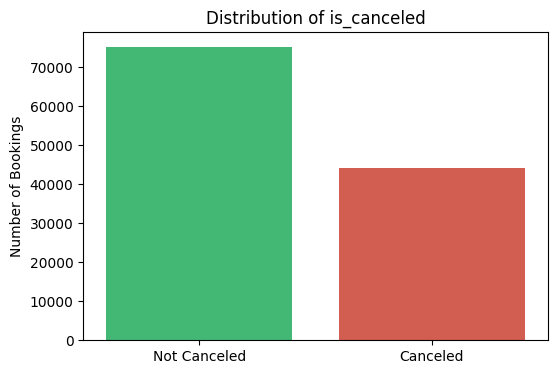

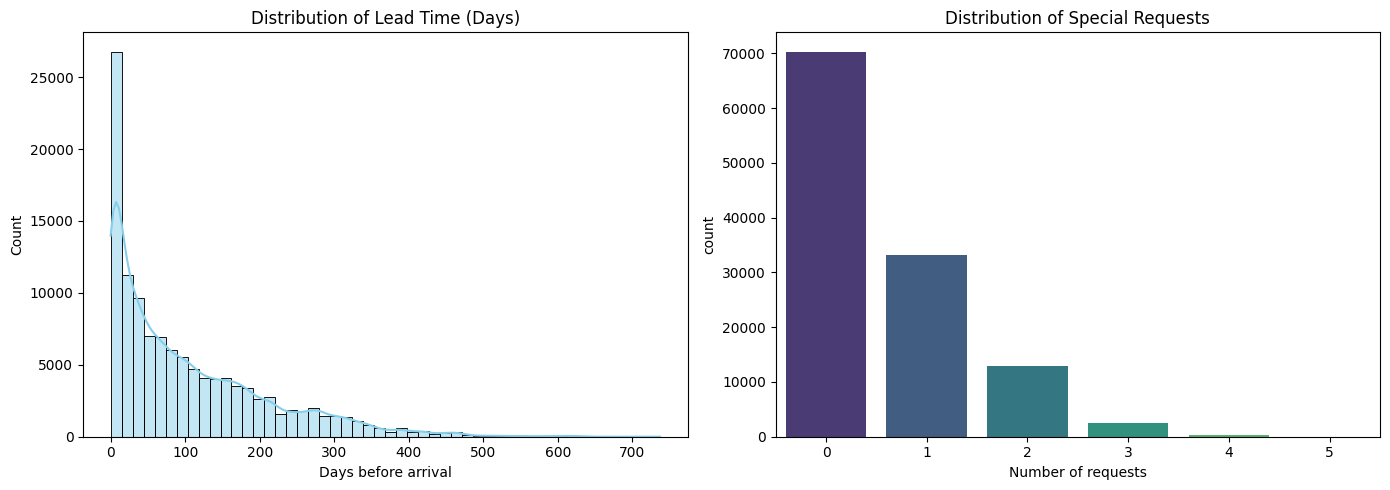


 Categorical Cardinality (Unique values):
   hotel: 2 unique values
   meal: 5 unique values
   country: 178 unique values
   market_segment: 8 unique values
   deposit_type: 3 unique values
   customer_type: 4 unique values

 Current Cancellation Rate: 37.0%


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns


target_stats = df_clean.group_by('is_canceled').agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum() * 100).alias('percentage')
).sort('is_canceled')

print(target_stats)

plt.figure(figsize=(6, 4))
sns.barplot(x=['Not Canceled', 'Canceled'], y=target_stats['count'].to_list(), palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of is_canceled')
plt.ylabel('Number of Bookings')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['lead_time'].to_pandas(), bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Lead Time (Days)')
axes[0].set_xlabel('Days before arrival')

sns.countplot(x=df_clean['total_of_special_requests'].to_list(), ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Special Requests')
axes[1].set_xlabel('Number of requests')

plt.tight_layout()
plt.show()


cat_cols = ['hotel', 'meal', 'country', 'market_segment', 'deposit_type', 'customer_type']

print("\n Categorical Cardinality (Unique values):")
for col in cat_cols:
    if col in df_clean.columns:
        print(f"   {col}: {df_clean[col].n_unique()} unique values")

cancel_rate = target_stats.filter(pl.col('is_canceled') == 1)['percentage'][0]
print(f"\n Current Cancellation Rate: {cancel_rate:.1f}%")


### Выводы

*  Большинство бронирований завершаются успешно, но значительная часть - отменяется.

*  Большинство людей бронируют отель в последний момент. Чем раньше создана бронь, тем больше вероятность, что планы изменятся и она будет отменена.

*  Подавляющее большинство гостей (более 70 000) не оставляют никаких специальных запросов

* Как показал дальнейший анализ, гости с запросами  отменяют брони гораздо реже, чем те, кто ничего не просил.







/tmp/ipython-input-3529810751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean.to_pandas(), x='is_canceled', y='lead_time', palette=['#2ecc71', '#e74c3c'])


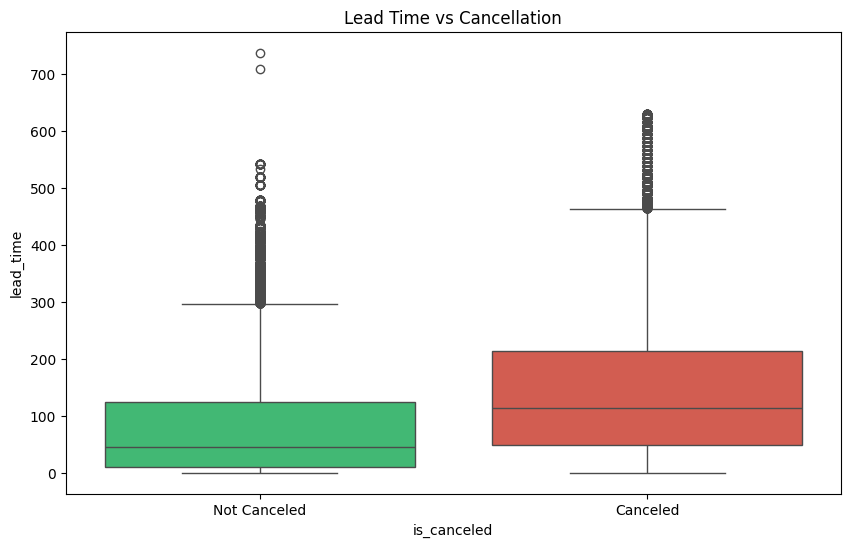

💳 Cancellation Rate by Deposit Type:
shape: (3, 3)
┌──────────────┬─────────────┬────────┐
│ deposit_type ┆ cancel_rate ┆ count  │
│ ---          ┆ ---         ┆ ---    │
│ str          ┆ f64         ┆ u32    │
╞══════════════╪═════════════╪════════╡
│ Non Refund   ┆ 0.993624    ┆ 14586  │
│ No Deposit   ┆ 0.283773    ┆ 104640 │
│ Refundable   ┆ 0.222222    ┆ 162    │
└──────────────┴─────────────┴────────┘


/tmp/ipython-input-3529810751.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=deposit_stats.to_pandas(), x='deposit_type', y='cancel_rate', palette='viridis')


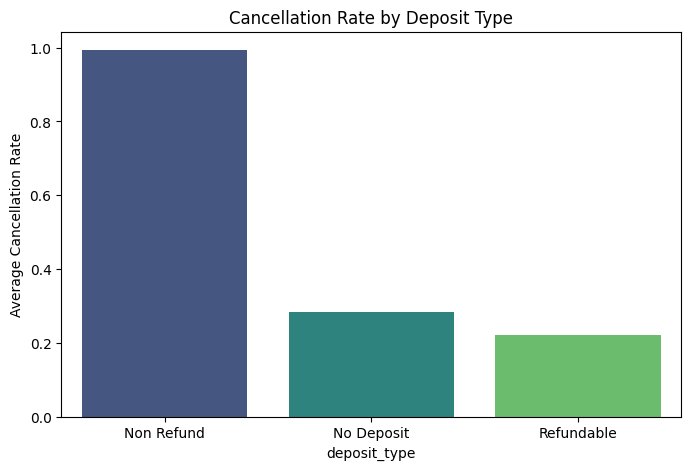

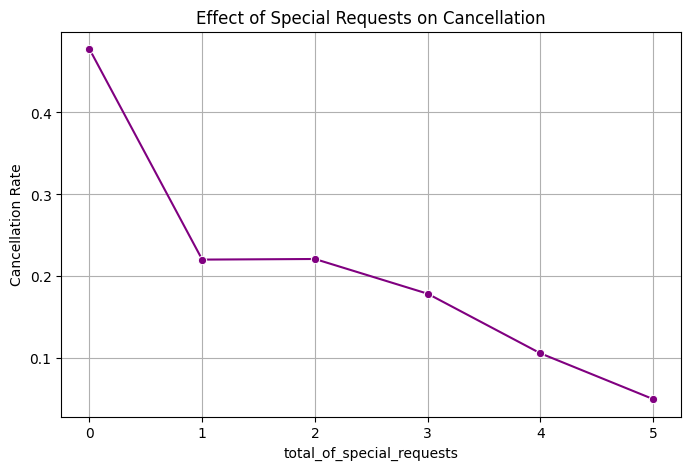

In [8]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean.to_pandas(), x='is_canceled', y='lead_time', palette=['#2ecc71', '#e74c3c'])
plt.title('Lead Time vs Cancellation')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

deposit_stats = df_clean.group_by('deposit_type').agg([
    pl.col('is_canceled').mean().alias('cancel_rate'),
    pl.len().alias('count')
]).sort('cancel_rate', descending=True)

print(deposit_stats)

plt.figure(figsize=(8, 5))
sns.barplot(data=deposit_stats.to_pandas(), x='deposit_type', y='cancel_rate', palette='viridis')
plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Average Cancellation Rate')
plt.show()


requests_stats = df_clean.group_by('total_of_special_requests').agg(
    pl.col('is_canceled').mean().alias('cancel_rate')
).sort('total_of_special_requests')

plt.figure(figsize=(8, 5))
sns.lineplot(data=requests_stats.to_pandas(), x='total_of_special_requests', y='cancel_rate', marker='o', color='purple')
plt.title('Effect of Special Requests on Cancellation')
plt.ylabel('Cancellation Rate')
plt.grid(True)
plt.show()

Вот краткое описание признаков:

1.  Total Stay
    *   **Что это:** Сумма ночей (будни + выходные).
    *   **Зачем:** Разделяет короткие деловые поездки (стабильные) и длинные отпуска (чувствительные к изменениям планов).

2.  Family Size
    *   **Что это:** Сумма всех гостей (взрослые + дети).
    *   **Зачем:** Отличает одиночек от семей (сложная логистика, реже отменяют, если всё организовали).

3.  Room Mismatch
    *   **Что это:** Отличие полученного номера от забронированного.
    *   **Зачем:** Обычно означает бесплатное улучшение условий. Довольный гость почти никогда не отменяет бронь.

4.  Very Early Booking
    *   **Что это:** Бронь сделана более чем за 6 месяцев.
    *   **Зачем:** Зона риска. За полгода планы у людей меняются очень часто, вероятность отмены высокая.

5.  Had Changes
    *   **Что это:** Гость вносил правки после создания брони.
    *   **Зачем:** Признак живого интереса. Если человек тратит время на уточнение деталей, он действительно собирается приехать.

6.  ADR Per Person
    *   **Что это:** Стоимость номера / кол-во гостей.
    *   **Зачем:** Показывает реальную дороговизну. $200 для одного — дорого, для четверых — дешево. Помогает модели понять бюджет клиента.

7.  Arrival Month
    *   **Что это:** Месяц заезда числом.
    *   **Зачем:** Учитывает сезонный спрос. В пик сезона отменяют реже, так как сложно найти замену; в несезон отмены чаще.

In [24]:

df_engineered = df_clean.with_columns(
    (pl.col('stays_in_weekend_nights') + pl.col('stays_in_week_nights')).alias('total_stay')
)

df_engineered = df_engineered.with_columns(
    (pl.col('adults') + pl.col('children') + pl.col('babies')).alias('family_size')
)

df_engineered = df_engineered.with_columns(
    (pl.col('reserved_room_type') != pl.col('assigned_room_type')).cast(pl.Int8).alias('room_mismatch')
)

df_engineered = df_engineered.with_columns([
    (pl.col('lead_time') > 180).cast(pl.Int8).alias('very_early_booking'),
    (pl.col('booking_changes') > 0).cast(pl.Int8).alias('had_changes'),
])

df_engineered = df_engineered.with_columns(
    pl.when(pl.col('family_size') > 0)
    .then(pl.col('adr') / pl.col('family_size'))
    .otherwise(pl.col('adr'))
    .alias('adr_per_person')
)

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df_engineered = df_engineered.with_columns(
    pl.col('arrival_date_month').replace(month_map).alias('arrival_month')
)


In [25]:
display(df_engineered.head())

hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay,family_size,room_mismatch,very_early_booking,had_changes,adr_per_person,arrival_month
str,i64,i64,i64,str,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,i64,i64,i64,str,str,i64,str,f64,f64,i64,str,f64,i64,i64,i64,f64,i8,i8,i8,f64,str
"""Resort Hotel""",0,342,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",3,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0,0,2.0,0,1,1,0.0,"""7"""
"""Resort Hotel""",0,737,2015,"""July""",27,1,0,0,2,0.0,0,"""BB""","""PRT""","""Direct""","""Direct""",0,0,0,"""C""","""C""",4,"""No Deposit""",null,null,0,"""Transient""",0.0,0,0,0,2.0,0,1,1,0.0,"""7"""
"""Resort Hotel""",0,7,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Direct""","""Direct""",0,0,0,"""A""","""C""",0,"""No Deposit""",null,null,0,"""Transient""",75.0,0,0,1,1.0,1,0,0,75.0,"""7"""
"""Resort Hotel""",0,13,2015,"""July""",27,1,0,1,1,0.0,0,"""BB""","""GBR""","""Corporate""","""Corporate""",0,0,0,"""A""","""A""",0,"""No Deposit""",304.0,null,0,"""Transient""",75.0,0,0,1,1.0,0,0,0,75.0,"""7"""
"""Resort Hotel""",0,14,2015,"""July""",27,1,0,2,2,0.0,0,"""BB""","""GBR""","""Online TA""","""TA/TO""",0,0,0,"""A""","""A""",0,"""No Deposit""",240.0,null,0,"""Transient""",98.0,0,1,2,2.0,0,0,0,49.0,"""7"""


In [27]:
df_engineered = df_engineered.with_columns([
    (pl.col('previous_cancellations') /
     (pl.col('previous_cancellations') + pl.col('previous_bookings_not_canceled') + 0.01)
    ).alias('guest_cancel_ratio'),


    ((pl.col('children') + pl.col('babies')) > 0).cast(pl.Int8).alias('has_kids'),

    ((pl.col('is_repeated_guest') == 0) & (pl.col('total_of_special_requests') == 0)).cast(pl.Int8).alias('new_guest_no_requests'),
])

## Part 1: Fit the model

Write basic model building and validation procedure. At this point you don't need to pick hyperparameters intensively. You may check a few by hand if you want.

In [28]:
from sklearn.model_selection import train_test_split


cols_to_drop = [
    'arrival_date_month', 'arrival_date_year', 'arrival_date_day_of_month',
    'arrival_date_week_number', 'company', 'is_canceled'
]

X = df_engineered.drop([c for c in cols_to_drop if c in df_engineered.columns]).to_pandas()
y = df_engineered['is_canceled'].to_pandas()

cat_features = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype.name == 'category']


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Итоговое разделение:")
print(f"Обучение:   {X_train.shape[0]} строк")
print(f"Валидация:  {X_val.shape[0]} строк")
print(f"Тест:       {X_test.shape[0]} строк")


print(f"Всего признаков: {X_train.shape[1]}")
print(f"Категориальные: {cat_features}")

Итоговое разделение:
Обучение:   71632 строк
Валидация:  23878 строк
Тест:       23878 строк
Всего признаков: 36
Категориальные: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'arrival_month', 'segment_deposit_mix']


### Metrics and plots

Calculate main metrics for classification problem which you think are relevant from those we discussed on lecture (at least 3).

Visualize them over training process for train and validation sests.

In [18]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


Посмотрим на качество CatBoostClassifier


In [29]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

for col in cat_features:
    X_train[col] = X_train[col].fillna('Unknown').astype(str)
    X_val[col] = X_val[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)


train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# model = CatBoostClassifier(
#     task_type="GPU",
#     iterations=1000,
#     learning_rate=0.05,
#     depth=10,
#     eval_metric='Accuracy',
#     random_seed=42,
#     verbose=200
# )


# model.fit(
#     train_pool,
#     eval_set=val_pool,
#     early_stopping_rounds=100,
#     use_best_model=True
# )

model = CatBoostClassifier(
    task_type="GPU",

    iterations=2000,

    learning_rate=0.03,

    depth=10,

    l2_leaf_reg=5,

    random_strength=2,

    bagging_temperature=0.5,

    min_data_in_leaf=20,

    eval_metric='Accuracy',

    random_seed=42,

    verbose=200
)

model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=150,
    use_best_model=True
)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

feature_importance = model.get_feature_importance(prettified=True)
display(feature_importance.head(10))

0:	learn: 0.8308996	test: 0.8290895	best: 0.8290895 (0)	total: 168ms	remaining: 5m 36s
200:	learn: 0.8762564	test: 0.8675768	best: 0.8678281 (197)	total: 18.8s	remaining: 2m 48s
400:	learn: 0.8894488	test: 0.8736494	best: 0.8736913 (391)	total: 36.3s	remaining: 2m 24s
600:	learn: 0.9052937	test: 0.8790518	best: 0.8790518 (600)	total: 55.3s	remaining: 2m 8s
800:	learn: 0.9177323	test: 0.8816903	best: 0.8818578 (787)	total: 1m 13s	remaining: 1m 49s
1000:	learn: 0.9275743	test: 0.8828210	best: 0.8832817 (983)	total: 1m 31s	remaining: 1m 31s
1200:	learn: 0.9361598	test: 0.8834073	best: 0.8838261 (1141)	total: 1m 49s	remaining: 1m 13s
bestTest = 0.8838261161
bestIteration = 1141
Shrink model to first 1142 iterations.
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     15033
           1       0.86      0.82      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.88      0.87      0.87     23878
weight

,Feature Id,Importances
0,country,13.832109
1,lead_time,8.185050
2,agent,7.762910
3,arrival_month,5.910778
4,required_car_parking_spaces,4.906317
5,segment_deposit_mix,4.900672
6,market_segment,4.595324
7,customer_type,4.533714
8,deposit_type,4.491790
9,adr,3.965615


Посмотрим на качество XGBClassifier


In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

obj_cols = X_train_xgb.select_dtypes(include=['object']).columns.tolist()

encoders = {}
for col in obj_cols:
    le = LabelEncoder()
    le.fit(list(X_train_xgb[col].astype(str)) + list(X_val_xgb[col].astype(str)) + list(X_test_xgb[col].astype(str)))
    X_train_xgb[col] = le.transform(X_train_xgb[col].astype(str))
    X_val_xgb[col] = le.transform(X_val_xgb[col].astype(str))
    X_test_xgb[col] = le.transform(X_test_xgb[col].astype(str))
    encoders[col] = le

xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=100
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=200
)

proba = xgb_model.predict_proba(X_test_xgb)[:, 1]

best_t, best_acc = 0.5, 0
for t in [0.40, 0.42, 0.44, 0.46, 0.48, 0.50, 0.52]:
    pred = (proba >= t).astype(int)
    acc = accuracy_score(y_test, pred)
    print(f"t={t}: acc={acc:.4f}")
    if acc > best_acc:
        best_acc, best_t = acc, t

print(f"\n XGB best acc={best_acc:.4f} @ t={best_t}")

pred_best = (proba >= best_t).astype(int)
print("\nClassification report (XGB):")
print(classification_report(y_test, pred_best))

[0]	validation_0-logloss:0.64427
[200]	validation_0-logloss:0.27668
[400]	validation_0-logloss:0.25828
[600]	validation_0-logloss:0.25225
[800]	validation_0-logloss:0.25023
[1000]	validation_0-logloss:0.24950
[1106]	validation_0-logloss:0.24985
t=0.4: acc=0.8856
t=0.42: acc=0.8864
t=0.44: acc=0.8874
t=0.46: acc=0.8875
t=0.48: acc=0.8879
t=0.5: acc=0.8880
t=0.52: acc=0.8877

 XGB best acc=0.8880 @ t=0.5

Classification report (XGB):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     15033
           1       0.87      0.83      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.88      0.88      0.88     23878
weighted avg       0.89      0.89      0.89     23878



### Conclusion on basic model results

Благодаря качественному EDA на базовой модели получилось достичь качества 88% без какого-то продвинутого подобора гиперпараметров.

## Part 2: Use hyper parameter tuning system

Use [optuna](https://optuna.org/) or [hyperopt](http://hyperopt.github.io/hyperopt/) zero order optimizer to find optimal hyper param set.

Попробуем подобрать гиперпараметры с поомщью optuna

In [22]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 16.3 MB/s eta 0:00:00


In [31]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    params = {
        "task_type": "GPU",
        "loss_function": trial.suggest_categorical("loss_function", ["Logloss", "CrossEntropy"]),
        "eval_metric": "Accuracy",
        "iterations": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 6, 10),

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 50, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.5, 10, log=True),

        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200, log=True),

        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),

        "od_type": "Iter",
        "od_wait": 200,

        "cat_features": cat_features,

        "random_seed": 42,
        "verbose": False
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 10.0)
    else:
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)

    model = CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        use_best_model=True
    )

    val_proba = model.predict_proba(X_val)[:, 1]

    best_acc = 0
    for t in [0.42, 0.44, 0.46, 0.48, 0.50]:
        preds = (val_proba >= t).astype(int)
        acc = accuracy_score(y_val, preds)
        best_acc = max(best_acc, acc)

    return best_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("\n Лучшие параметры:")
print(study.best_params)
print(f"Лучшая accuracy на валидации: {study.best_value:.4f}")

[I 2025-12-26 18:59:09,754] A new study created in memory with name: no-name-285ac669-424c-4c90-88ca-f7f812e5f7df
[I 2025-12-26 19:03:47,114] Trial 0 finished with value: 0.8832816818829048 and parameters: {'loss_function': 'Logloss', 'learning_rate': 0.024737453965268427, 'depth': 10, 'l2_leaf_reg': 48.15002768637294, 'random_strength': 6.246147592410398, 'min_data_in_leaf': 197, 'bootstrap_type': 'Bernoulli', 'subsample': 0.7266326776177496}. Best is trial 0 with value: 0.8832816818829048.
[I 2025-12-26 19:06:08,095] Trial 1 finished with value: 0.8218862551302454 and parameters: {'loss_function': 'CrossEntropy', 'learning_rate': 0.018336252000753117, 'depth': 8, 'l2_leaf_reg': 1.274499874825783, 'random_strength': 0.955469250988395, 'min_data_in_leaf': 66, 'bootstrap_type': 'MVS', 'subsample': 0.9405481677328911}. Best is trial 0 with value: 0.8832816818829048.
[I 2025-12-26 19:08:03,407] Trial 2 finished with value: 0.8836585978725187 and parameters: {'loss_function': 'Logloss', 'l


 Лучшие параметры:
{'loss_function': 'Logloss', 'learning_rate': 0.018459518213281997, 'depth': 9, 'l2_leaf_reg': 2.4100206207460464, 'random_strength': 9.791460069491086, 'min_data_in_leaf': 26, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.18800031432091563}
Лучшая accuracy на валидации: 0.8860


### Conclusion

Глубина деревьев (depth): Подтверждена критическая важность высокой глубины. Лучший результат (Trial 12) достигнут при depth = 9. Модели с глубиной 6-7 (Trial 8, 15) показывают значительно более низкую точность.


Скорость обучения (learning_rate): Оптимальный диапазон сместился в сторону более консервативных значений: 0.015 – 0.025. Лучшая модель использовала 0.018. Более высокие значения (выше 0.05) приводили к преждевременной остановке из-за переобучения.

Функция потерь (loss_function): Logloss остается безусловным лидером. Попытки использовать CrossEntropy (Trial 1, 5, 6) стабильно давали худшие результаты или приводили к нестабильности обучения.

Регуляризация и устойчивость: В лучшей попытке значение l2_leaf_reg составило 2.41, что в сочетании с высоким random_strength (9.79) позволило модели эффективно обобщать данные, не переобучаясь на редких категориях.

## Part 3. Interpret the model predictions

Train model with the best hparams you've found and analyze it.

Please use [shap](https://github.com/slundberg/shap) to build beeswarm plot and at least one more of your choice and interpret them (in a conclusion section below).

In [32]:
final_params = study.best_params.copy()
final_params.update({
    "task_type": "GPU",
    "iterations": 2000,
    "cat_features": cat_features,
    "random_seed": 42,
    "verbose": False
})
final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)

📊 SHAP Beeswarm Plot:


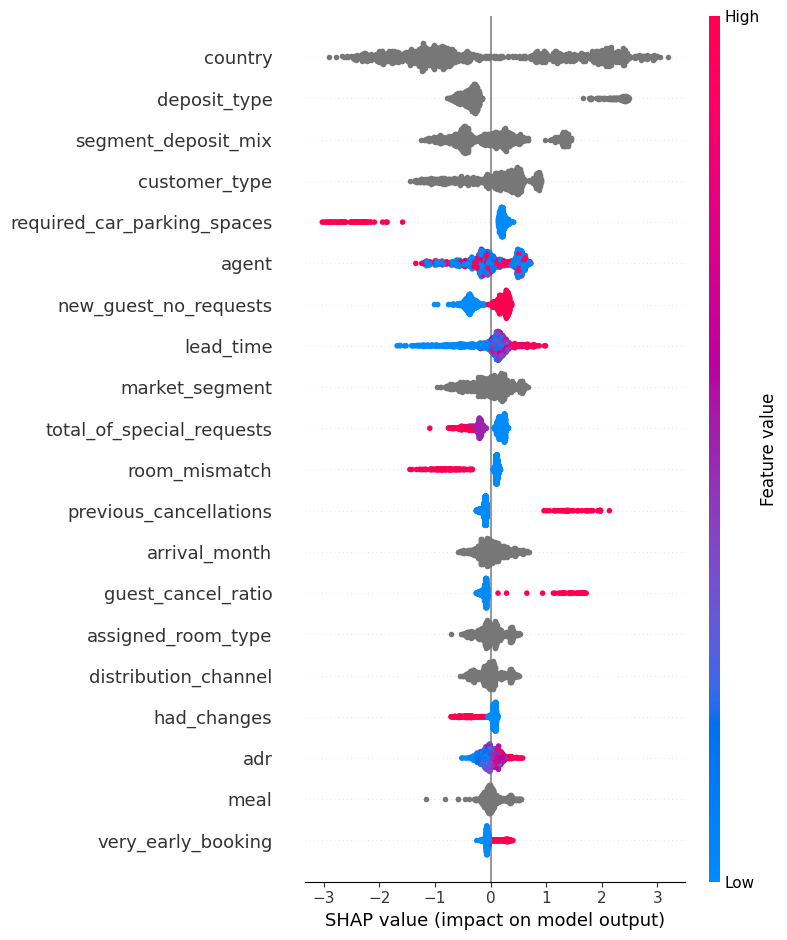

In [ ]:
import shap


X_sample = X_test.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)


shap.summary_plot(shap_values, X_sample, plot_type="dot", show=True)

### Conclusion

Your thoughts about the plots and model behaviour (not limited to duplicating features):

deposit_type и segment_deposit_mix: Безвозвратный депозит (Non Refund) является сильнейшим сигналом к отмене.

Страна происхождения гостя имеет критическое значение. Модель выявила географические паттерны, где жители определенных регионов склонны отменять брони чаще.

required_car_parking_spaces: Если гостю нужно парковочное место, вероятность отмены стремится к нулю.

total_of_special_requests: Наличие спецзапросов значительно снижает риск. Вовлеченность гостя в детали поездки - прямой признак намерения приехать.

lead_time: Подтверждена гипотеза «чем раньше бронь, тем выше риск». Длинный период ожидания дает больше времени на смену планов или поиск альтернатив.

room_mismatch: Получение номера, отличного от забронированного, снижает вероятность отмены.

Созданные признаки, такие как new_guest_no_requests и guest_cancel_ratio, вошли в топ-10 по важности.
